In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#load a npz file named "outputs_attention_unet/predictions_targets.npz" and extract the arrays "predictions" and "targets"
data = np.load("validation_predictions_with_actuals.npz")

In [3]:
#see the file
print(data.files)

['predictions', 'actuals', 'masked_predictions', 'masked_actuals', 'mask', 'year', 'input_start_day', 'target_start_day', 'target_day_t1', 'target_day_t2', 'target_day_t3']


In [4]:
#extract only the masked_predictions
predictions = data["masked_predictions"]
targets = data["masked_actuals"]

In [5]:
print(predictions.shape)
print(targets.shape)

(719, 3, 33, 25)
(719, 3, 33, 25)


In [6]:
mask = data["mask"]

In [7]:
#make mse a numpy float array of shape (3,) and initialize it with np.zero
max_mse = np.zeros(3)
min_mse = np.inf * np.ones(3)
idx_worst = np.array([-1, -1, -1])
idx_best = np.array([-1, -1, -1])
for i in range(predictions.shape[0]):
    mse = mean_squared_error(targets[i][0], predictions[i][0])
    if max_mse[0]<mse:
        max_mse[0] = mse
        idx_worst[0] = i
    if min_mse[0]>mse:
        min_mse[0] = mse
        idx_best[0] = i
    mse = mean_squared_error(targets[i][1], predictions[i][1])
    if max_mse[1]<mse:
        max_mse[1] = mse
        idx_worst[1] = i
    if min_mse[1]>mse:
        min_mse[1] = mse
        idx_best[1] = i
    mse = mean_squared_error(targets[i][2], predictions[i][2])
    if max_mse[2]<mse:
        max_mse[2] = mse
        idx_worst[2] = i
    if min_mse[2]>mse:
        min_mse[2] = mse
        idx_best[2] = i

    

In [8]:
print(max_mse)
print(min_mse)
print(idx_worst)
print(idx_best)

[0.00143176 0.00369721 0.00447063]
[2.81719758e-06 2.83584745e-06 2.86357340e-06]
[118  51  51]
[339 380 380]


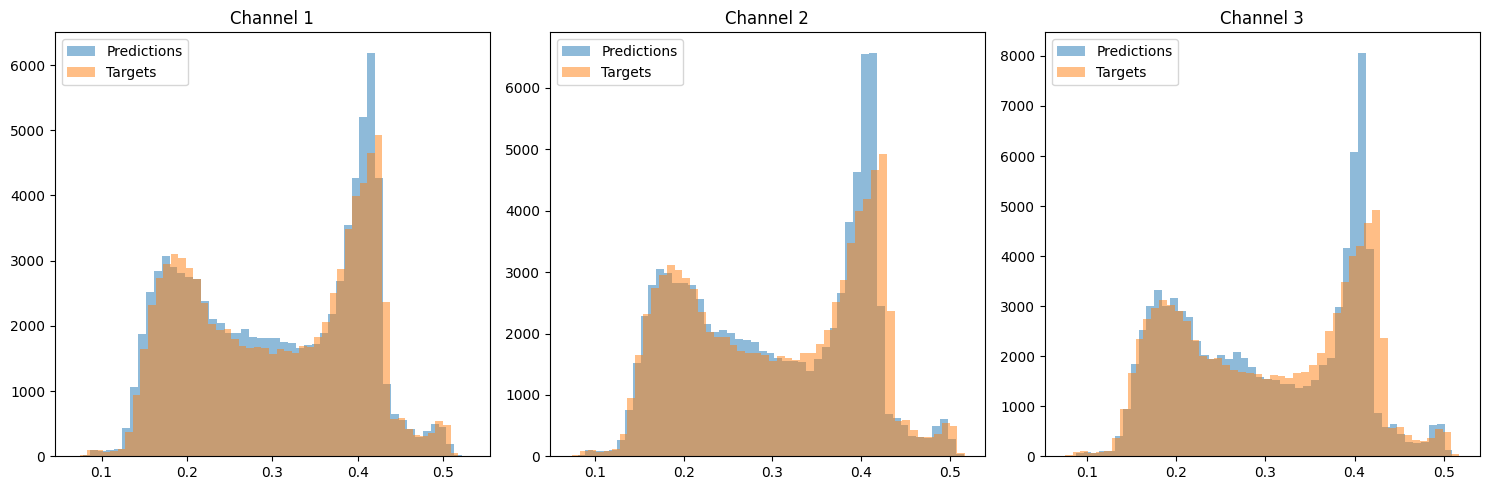

In [12]:
#plot histogram of actual and predicted values frequency for all three channels for all data points
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.hist(predictions[:, i][predictions[:, i] != 0], bins=50, alpha=0.5, label='Predictions')
    plt.hist(targets[:, i][targets[:, i] != 0], bins=50, alpha=0.5, label='Targets')
    plt.legend()
    plt.title(f'Channel {i+1}')
plt.tight_layout()
plt.show()


In [9]:
# #plot the worst predicted, actual and scatterplot
# for i in range(3):
#     plt.figure(figsize=(15, 5))
#     plt.subplot(1, 3, 1)
#     plt.imshow(predictions[idx_worst[i]][i], cmap="viridis")
#     plt.colorbar()
#     plt.title(f"Worst Predicted (T+{i+1})")
#     plt.subplot(1, 3, 2)
#     plt.imshow(targets[idx_worst[i]][i], cmap="viridis")
#     plt.colorbar()
#     plt.title(f"Actual (T+{i+1})")
#     plt.subplot(1, 3, 3)
#     plt.scatter(targets[idx_worst[i]][i].flatten(), predictions[idx_worst[i]][i].flatten())
#     plt.title(f"Scatter Plot (T+{i+1})")
#     #plot y = x for max y and x
#     max_val = max(np.max(targets[idx_worst[i]][i]), np.max(predictions[idx_worst[i]][i]))
#     plt.plot([0, max_val], [0, max_val], "b--", alpha=0.5)
#     plt.xlabel("Actual")
#     plt.ylabel("Predicted")
#     plt.grid()
#     plt.show()

In [10]:
# #now the best predicted, actual and scatterplot
# for i in range(3):
#     plt.figure(figsize=(15, 5))
#     plt.subplot(1, 3, 1)
#     plt.imshow(predictions[idx_best[i]][i], cmap="viridis")
#     plt.colorbar()
#     plt.title(f"Best Predicted (T+{i+1})")
#     plt.subplot(1, 3, 2)
#     plt.imshow(targets[idx_best[i]][i], cmap="viridis")
#     plt.colorbar()
#     plt.title(f"Actual (T+{i+1})")
#     plt.subplot(1, 3, 3)
#     plt.scatter(targets[idx_best[i]][i].flatten(), predictions[idx_best[i]][i].flatten())
#     plt.title(f"Scatter Plot (T+{i+1})")
#     #plot y = x for max y and x
#     max_val = max(np.max(targets[idx_best[i]][i]), np.max(predictions[idx_best[i]][i]))
#     plt.plot([0, max_val], [0, max_val], "b--", alpha=0.5)
#     plt.xlabel("Actual")
#     plt.ylabel("Predicted")
#     plt.grid()
#     plt.show()